---
title: "Credit Card Fraud Detection with TabPFN"
description: "Flag fraudulent card transactions on the Kaggle credit card fraud dataset with the TabPFN client: no resampling, no feature engineering, compared against the XGBoost and random forest setups from popular Kaggle notebooks"
icon: "credit-card"
cookbookTags:
  - classification
  - fraud
authors:
  - name: Philipp Singer
    linkedin: https://www.linkedin.com/in/philippsinger
    twitter: https://twitter.com/ph_singer
---

*Fraud detection on the raw dataframe: fit, predict, done.*

The [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) dataset is one of the
most used tables on Kaggle. It holds 284,807 card transactions from two days in September 2013, of which only
492 (0.172%) are fraudulent. The features are 28 anonymized PCA components plus the transaction `Time` and
`Amount`. The dataset authors recommend the **area under the precision-recall curve (AUPRC)** as the metric,
because accuracy and even ROC AUC say little when one class is this rare.

Most public notebooks on this dataset spend their effort on the imbalance: undersampling, SMOTE, class weights,
threshold sweeps. [TabPFN](https://github.com/PriorLabs/TabPFN) is a tabular foundation model that predicts in a
single forward pass with no per-dataset training, and it is robust to imbalance out of the box. This notebook
hands it the raw dataframe through the hosted API (`tabpfn-client`), so no GPU is needed, and compares the
result with the reference models from the most popular Kaggle notebooks, trained on exactly the same columns
with no feature engineering, so the comparison stays fair.

**Bottom line up front:**

- **One fit, one predict, no imbalance tricks.** TabPFN reaches an AUPRC of about **0.90** and a ROC AUC of
  about **0.99** on a held-out 20% split, straight from the 30 raw columns.
- **Ahead of the Kaggle reference models on the same columns.** On the same split, the XGBoost
  configuration from the most popular modeling notebook reaches 0.84 AUPRC, a 100-tree random forest 0.87,
  and XGBoost with library defaults 0.78.
- **The ranking holds across folds.** In a 5-fold stratified cross-validation TabPFN wins every fold, with a
  mean AUPRC of 0.89 against 0.85 for the random forest and 0.81 for the reference XGBoost, so the conclusion
  does not rest on a single set of 98 test frauds.

## Setup

*Installing the TabPFN client, the Kaggle download helper, and the reference models.*

In [ ]:
!pip install tabpfn-client kagglehub xgboost scikit-learn pandas matplotlib

## Load the data

*Downloading the dataset from Kaggle and taking a first look.*

`kagglehub` downloads public datasets without a Kaggle account. The table has no missing values, and all 30
feature columns are numeric. We drop nothing and engineer nothing: `Time` (seconds since the first
transaction), `Amount`, and `V1` to `V28` go into every model exactly as they arrive.

In [1]:
import os
import time
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier

# tabpfn-client warns that the full-output criterion needs the local tabpfn package; not needed here.
warnings.filterwarnings("ignore", message="Optional dependencies 'tabpfn' and 'torch'")

RANDOM_STATE = 42

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

X = df.drop(columns="Class")
y = df["Class"]
print(f"{len(df):,} transactions | {X.shape[1]} features | "
      f"{int(y.sum()):,} frauds ({100 * y.mean():.3f}%)")
df.head()

284,807 transactions | 30 features | 492 frauds (0.173%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Train/test split

*A stratified 80/20 split, the setup used by the Kaggle notebooks we compare against.*

Stratification keeps the fraud rate identical in both halves, which leaves 98 frauds in the test set.
The public notebooks split at random, and we follow them so the reference numbers are comparable. A
production fraud model would be validated out of time (train on the first day, test on the second) to
catch drift; the cross-validation at the end of this notebook is the more robust check within this
protocol.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train {len(X_train):,} rows / {int(y_train.sum())} frauds | "
      f"test {len(X_test):,} rows / {int(y_test.sum())} frauds")

train 227,845 rows / 394 frauds | test 56,962 rows / 98 frauds


## Metrics

*AUPRC as the headline, ROC AUC for reference, and one operational number.*

- **AUPRC** (average precision) summarizes precision against recall across all thresholds. A model with no
  information scores the fraud rate, here 0.0017, so every gain is visible. This is the metric the dataset
  authors recommend.
- **ROC AUC** measures how well frauds rank above legitimate transactions. It is the most reported number on
  Kaggle, but on data this imbalanced it saturates near 1 and hides real differences.
- **Frauds in the top 100**: if an analyst team can review 100 transactions out of the 56,962 in the test set,
  how many of the 98 frauds are among the 100 highest-scored? This is what a review queue actually sees.

Every model records its scores and timings into one `results` list for the final table.

In [3]:
results = []


def evaluate(name, proba, fit_s, predict_s, notes=""):
    top_100 = int(y_test.to_numpy()[np.argsort(-proba)[:100]].sum())
    results.append(
        {
            "Model": name,
            "AUPRC": average_precision_score(y_test, proba),
            "ROC AUC": roc_auc_score(y_test, proba),
            "Frauds in top 100": top_100,
            "Fit time": f"{fit_s:.1f}s",
            "Predict time": f"{predict_s:.1f}s",
            "Notes": notes,
        }
    )
    print(f"{name}: AUPRC {results[-1]['AUPRC']:.4f} | ROC AUC {results[-1]['ROC AUC']:.4f} | "
          f"{top_100} of {int(y_test.sum())} frauds in the top 100")

## Authentication

*Setting the API token so the client can reach the hosted model.*

The client reads the API key through `set_access_token`. Here we pull it from Colab secrets; outside Colab,
set the `TABPFN_TOKEN` environment variable. Get a token at
[platform.priorlabs.ai](https://platform.priorlabs.ai).

In [4]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(userdata.get("TABPFN_TOKEN"))

## TabPFN

*Default settings, the raw dataframe, no resampling.*

`fit` uploads the training table; the model does its in-context learning on Prior Labs' servers when
`predict_proba` is called, so the predict timing includes the round-trip for the 227,845 training rows. There
are no hyperparameters to set and no class weights to pick.

In [5]:
tabpfn = TabPFNClassifier()

t0 = time.perf_counter()
tabpfn.fit(X_train, y_train)
fit_tabpfn = time.perf_counter() - t0

t0 = time.perf_counter()
proba_tabpfn = tabpfn.predict_proba(X_test)[:, 1]
predict_tabpfn = time.perf_counter() - t0

evaluate("TabPFN 3.5 (client, default)", proba_tabpfn, fit_tabpfn, predict_tabpfn, "hosted API")

TabPFN 3.5 (client, default): AUPRC 0.9014 | ROC AUC 0.9902 | 85 of 98 frauds in the top 100


## Reference models from Kaggle

*The same 30 columns, the model configurations the community converged on.*

We take the reference models from public notebooks on this dataset, keeping their configurations and dropping
any resampling or feature engineering:

- **XGBoost, Kaggle configuration.** Gabriel Preda's
  [Credit Card Fraud Detection Predictive Models](https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models)
  is the most upvoted modeling notebook on the dataset that trains on the raw columns. Its XGBoost uses
  shallow trees (`max_depth=2`), a learning rate of 0.039, row and column subsampling, and up to 1,000
  boosting rounds with early stopping on a validation slice. We reproduce that recipe, carving the validation
  slice out of our training set so the test set stays untouched.
- **XGBoost, library defaults.** Several notebooks, for example
  [ANNs vs XGBoost](https://www.kaggle.com/code/faressayah/credit-card-fraud-detection-anns-vs-xgboost),
  simply call `XGBClassifier()`.
- **Random forest.** The 100-tree `RandomForestClassifier` that opens Preda's notebook, and a common
  first model in many others.

The most upvoted notebook overall,
[Dealing with Imbalanced Datasets](https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets),
undersamples the majority class before training and evaluates on the balanced subset, so its numbers are not
comparable to a full test set and we do not reproduce it.

In [6]:
def fit_xgb_reference(X_fit, y_fit):
    """XGBoost as configured in the Kaggle reference notebook, early-stopped on a validation slice."""
    X_inner, X_valid, y_inner, y_valid = train_test_split(
        X_fit, y_fit, test_size=0.2, stratify=y_fit, random_state=RANDOM_STATE
    )
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.039,
        max_depth=2,
        subsample=0.8,
        colsample_bytree=0.9,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_inner, y_inner, eval_set=[(X_valid, y_valid)], verbose=False)
    return model


t0 = time.perf_counter()
xgb_ref = fit_xgb_reference(X_train, y_train)
fit_s = time.perf_counter() - t0
t0 = time.perf_counter()
proba_xgb_ref = xgb_ref.predict_proba(X_test)[:, 1]
evaluate("XGBoost (Kaggle configuration)", proba_xgb_ref, fit_s, time.perf_counter() - t0,
         f"max_depth=2, early stopping, best_iteration={xgb_ref.best_iteration}")

t0 = time.perf_counter()
xgb_default = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
fit_s = time.perf_counter() - t0
t0 = time.perf_counter()
proba_xgb_default = xgb_default.predict_proba(X_test)[:, 1]
evaluate("XGBoost (library defaults)", proba_xgb_default, fit_s, time.perf_counter() - t0,
         "XGBClassifier()")

t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
fit_s = time.perf_counter() - t0
t0 = time.perf_counter()
proba_rf = rf.predict_proba(X_test)[:, 1]
evaluate("Random forest (100 trees)", proba_rf, fit_s, time.perf_counter() - t0, "n_estimators=100")

XGBoost (Kaggle configuration): AUPRC 0.8382 | ROC AUC 0.9719 | 82 of 98 frauds in the top 100
XGBoost (library defaults): AUPRC 0.7813 | ROC AUC 0.9219 | 79 of 98 frauds in the top 100
Random forest (100 trees): AUPRC 0.8734 | ROC AUC 0.9630 | 86 of 98 frauds in the top 100


## Results

*One table, four models, the same 30 columns.*

TabPFN leads on both ranking metrics and puts the most frauds into the top 100 without any threshold
tuning. Every ROC AUC sits above 0.92 and the top three are within three points of each other, which is
exactly why the dataset authors ask for AUPRC: there the spread between the same models is twelve points.
The tree models train in seconds on a CPU; TabPFN's time is the API round-trip for a 228k-row table, most
of it spent in `predict_proba`, where the hosted model does its in-context learning.

In [7]:
table = pd.DataFrame(results)
table["AUPRC"] = table["AUPRC"].map("{:.4f}".format)
table["ROC AUC"] = table["ROC AUC"].map("{:.4f}".format)
print(table.to_string(index=False))

                         Model  AUPRC ROC AUC  Frauds in top 100 Fit time Predict time                                           Notes
  TabPFN 3.5 (client, default) 0.9014  0.9902                 85     4.7s       171.7s                                      hosted API
XGBoost (Kaggle configuration) 0.8382  0.9719                 82     1.2s         0.0s max_depth=2, early stopping, best_iteration=110
    XGBoost (library defaults) 0.7813  0.9219                 79     0.4s         0.0s                                 XGBClassifier()
     Random forest (100 trees) 0.8734  0.9630                 86     2.8s         0.0s                                n_estimators=100


## Precision-recall curves

*Where the AUPRC gap comes from.*

The curves show precision (how many flagged transactions are fraud) against recall (how many frauds are
caught). TabPFN holds higher precision as recall increases, which is the regime a fraud team operates in:
catch most of the fraud without drowning analysts in false alarms. The dashed line is the fraud rate, the
precision of flagging at random.

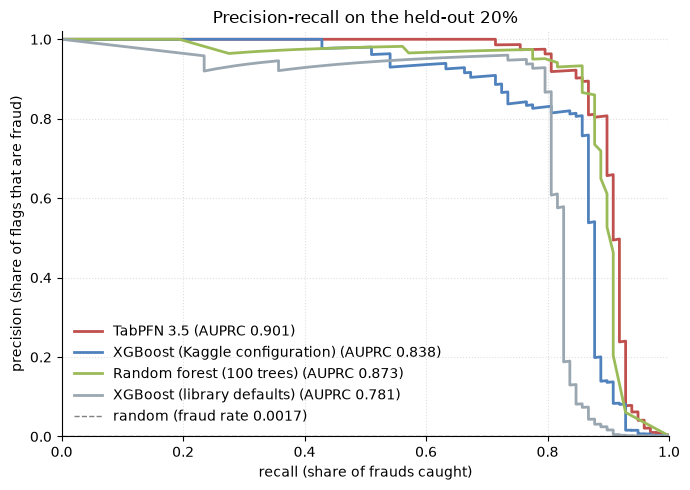

In [8]:
curves = [
    ("TabPFN 3.5", proba_tabpfn, "#c0504d"),
    ("XGBoost (Kaggle configuration)", proba_xgb_ref, "#4f81bd"),
    ("Random forest (100 trees)", proba_rf, "#9bbb59"),
    ("XGBoost (library defaults)", proba_xgb_default, "#9aa7b0"),
]

fig, ax = plt.subplots(figsize=(7, 5))
for name, proba, color in curves:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax.plot(recall, precision, color=color, lw=2,
            label=f"{name} (AUPRC {average_precision_score(y_test, proba):.3f})")
ax.axhline(y_test.mean(), ls="--", color="grey", lw=1, label=f"random (fraud rate {y_test.mean():.4f})")
ax.set(xlabel="recall (share of frauds caught)", ylabel="precision (share of flags that are fraud)",
       xlim=(0, 1), ylim=(0, 1.02), title="Precision-recall on the held-out 20%")
ax.grid(ls=":", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

## Is one split enough?

*Repeating the comparison with 5-fold stratified cross-validation.*

A test set with 98 frauds is small, and the AUPRC of any model moves by a few points from split to split. To
check that the ranking is not an artifact of one split, we run all models on five stratified folds. Each
model is fit on 80% of the data and scored on the remaining 20%, so every transaction is a test row exactly
once. Same columns, same configurations, no tuning on the folds. This cell makes five TabPFN calls of the
same size as the one above, so it takes a few times longer.

In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    row = {"Fold": fold, "Test frauds": int(y_te.sum())}
    row["TabPFN 3.5"] = average_precision_score(
        y_te, TabPFNClassifier().fit(X_tr, y_tr).predict_proba(X_te)[:, 1])
    row["XGBoost (Kaggle configuration)"] = average_precision_score(
        y_te, fit_xgb_reference(X_tr, y_tr).predict_proba(X_te)[:, 1])
    row["XGBoost (library defaults)"] = average_precision_score(
        y_te, XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(X_tr, y_tr).predict_proba(X_te)[:, 1])
    row["Random forest (100 trees)"] = average_precision_score(
        y_te, RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
        .fit(X_tr, y_tr).predict_proba(X_te)[:, 1])
    cv_rows.append(row)
    print(f"fold {fold}: " + " | ".join(f"{k} {v:.4f}" for k, v in row.items() if k not in ("Fold", "Test frauds")))

cv = pd.DataFrame(cv_rows).set_index("Fold")
model_cols = [c for c in cv.columns if c != "Test frauds"]
summary = pd.DataFrame({"mean AUPRC": cv[model_cols].mean(), "std": cv[model_cols].std(),
                        "folds won": (cv[model_cols].T == cv[model_cols].max(axis=1)).sum(axis=1)})
print()
print(summary.sort_values("mean AUPRC", ascending=False).to_string(float_format="{:.4f}".format))

fold 1: TabPFN 3.5 0.8663 | XGBoost (Kaggle configuration) 0.7898 | XGBoost (library defaults) 0.7572 | Random forest (100 trees) 0.8146
fold 2: TabPFN 3.5 0.9175 | XGBoost (Kaggle configuration) 0.8556 | XGBoost (library defaults) 0.8601 | Random forest (100 trees) 0.8856
fold 3: TabPFN 3.5 0.9109 | XGBoost (Kaggle configuration) 0.8160 | XGBoost (library defaults) 0.8211 | Random forest (100 trees) 0.8589
fold 4: TabPFN 3.5 0.8964 | XGBoost (Kaggle configuration) 0.8362 | XGBoost (library defaults) 0.8190 | Random forest (100 trees) 0.8450
fold 5: TabPFN 3.5 0.8642 | XGBoost (Kaggle configuration) 0.7575 | XGBoost (library defaults) 0.7553 | Random forest (100 trees) 0.8223

                                mean AUPRC    std  folds won
TabPFN 3.5                          0.8911 0.0248          5
Random forest (100 trees)           0.8453 0.0286          0
XGBoost (Kaggle configuration)      0.8110 0.0386          0
XGBoost (library defaults)          0.8025 0.0453          0


## Takeaways

- **No imbalance handling needed.** TabPFN sees 394 frauds among 227,845 rows and ranks them well without
  undersampling, SMOTE, or class weights. The default probabilities can be thresholded directly for a review
  queue.
- **No feature engineering, no tuning.** The reference models were configured by experienced Kaggle authors;
  TabPFN was not configured at all and still comes out ahead on AUPRC across the folds.
- **Fair comparison, real caveats.** All models saw the same 30 columns and a random stratified split. A
  production evaluation would split by time and would likely add merchant, card, and velocity features that
  this anonymized dataset cannot provide. For grouped or temporal fraud data, the
  [Thinking mode](https://docs.priorlabs.ai/capabilities/thinking-mode) of the client is a natural next step.